# Training CNN per FER-2013

Questo notebook addestra una CNN sulle immagini FER-2013 presenti nella repo.
Usa `data/processed/train` per il training, `data/processed/validation` per la validazione e mantiene `data/original/test` separato per la valutazione finale.

In [8]:
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


def count_images_by_class(root_dir, extension=".jpg"):
    root_dir = Path(root_dir)
    counts = {}
    if not root_dir.exists():
        return counts

    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        counts[class_dir.name] = len(list(class_dir.glob(f"*{extension}")))

    return counts


class EpochTimingLogger(Callback):
    def on_train_begin(self, logs=None):
        self.training_start = perf_counter()
        log_step("Training avviato")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = perf_counter()
        log_step(f"Epoca {epoch + 1} avviata")

    def on_epoch_end(self, epoch, logs=None):
        elapsed = perf_counter() - self.epoch_start
        logs = logs or {}
        metrics = []
        for key in ["loss", "accuracy", "auc", "val_loss", "val_accuracy", "val_auc"]:
            if key in logs:
                metrics.append(f"{key}={logs[key]:.4f}")

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        metrics.append(f"lr={lr:.2e}")
        log_step(f"Epoca {epoch + 1} completata in {elapsed:.1f}s - " + " | ".join(metrics))

    def on_train_end(self, logs=None):
        elapsed = perf_counter() - self.training_start
        log_step(f"Training terminato in {elapsed / 60:.1f} minuti")


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

log_step(f"TensorFlow: {tf.__version__}")
log_step(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")


[18:01:57] TensorFlow: 2.20.0
[18:01:57] GPU disponibili: []


## Dataset

Il notebook di preprocessing crea uno split fisico in `data/processed/train` e `data/processed/validation`.
Il test set resta in `data/original/test` e viene usato solo per la valutazione finale.

In [9]:
with timed_step("Configurazione percorsi"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    train_dir = project_root / "data" / "processed" / "train"
    validation_dir = project_root / "data" / "processed" / "validation"
    test_dir = project_root / "data" / "original" / "test"

    IMG_HEIGHT = 48
    IMG_WIDTH = 48
    BATCH_SIZE = 32

    if not train_dir.exists():
        raise FileNotFoundError(f"Cartella training preprocessata non trovata: {train_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not validation_dir.exists():
        raise FileNotFoundError(f"Cartella validation preprocessata non trovata: {validation_dir}. Esegui prima notebooks/Preprocessing.ipynb.")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    log_step(f"Project root: {project_root}")
    log_step(f"Training directory: {train_dir}")
    log_step(f"Validation directory: {validation_dir}")
    log_step(f"Test directory: {test_dir}")
    log_step(f"Batch size: {BATCH_SIZE}")


[18:02:00] INIZIO - Configurazione percorsi
[18:02:00] Project root: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward
[18:02:00] Training directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\train
[18:02:00] Validation directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\processed\validation
[18:02:00] Test directory: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\original\test
[18:02:00] Batch size: 32
[18:02:00] FINE - Configurazione percorsi (0.0s)


## Generatori

L augmentation viene applicata solo al training. Validation e test usano solo la normalizzazione, cosÃ¬ evitiamo data leakage.

In [10]:
with timed_step("Creazione generatori e class weights"):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    log_step("Creo train_generator con augmentation online")
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        seed=SEED
    )

    log_step("Creo validation_generator senza augmentation")
    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        seed=SEED,
        shuffle=False
    )

    log_step("Creo test_generator senza augmentation")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False
    )

    class_indices = train_generator.class_indices
    emotion_labels = {v: k for k, v in class_indices.items()}

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_generator.classes),
        y=train_generator.classes
    )
    class_weights = dict(enumerate(class_weights_array))

    train_counts = count_images_by_class(train_dir)
    validation_counts = count_images_by_class(validation_dir)
    test_counts = count_images_by_class(test_dir)

    log_step(f"Classi: {class_indices}")
    log_step(f"Training samples: {train_generator.samples} ({len(train_generator)} batch/epoca)")
    log_step(f"Validation samples: {validation_generator.samples} ({len(validation_generator)} batch)")
    log_step(f"Test samples: {test_generator.samples} ({len(test_generator)} batch)")

    for class_name in sorted(set(train_counts) | set(validation_counts) | set(test_counts)):
        log_step(
            f"{class_name}: train={train_counts.get(class_name, 0)}, "
            f"validation={validation_counts.get(class_name, 0)}, "
            f"test={test_counts.get(class_name, 0)}"
        )

    log_step(f"Class weights: {class_weights}")


[18:02:03] INIZIO - Creazione generatori e class weights
[18:02:03] Creo train_generator con augmentation online
Found 32155 images belonging to 7 classes.
[18:02:04] Creo validation_generator senza augmentation
Found 5741 images belonging to 7 classes.
[18:02:04] Creo test_generator senza augmentation
Found 7178 images belonging to 7 classes.
[18:02:04] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[18:02:04] Training samples: 32155 (1005 batch/epoca)
[18:02:04] Validation samples: 5741 (180 batch)
[18:02:04] Test samples: 7178 (225 batch)
[18:02:04] angry: train=4507, validation=799, test=958
[18:02:04] disgust: train=477, validation=87, test=111
[18:02:04] fear: train=4588, validation=819, test=1024
[18:02:04] happy: train=8062, validation=1443, test=1774
[18:02:04] neutral: train=5560, validation=993, test=1233
[18:02:04] sad: train=5407, validation=966, test=1247
[18:02:04] surprise: train=3554, validation=634, test=831
[18:02:04]

## Anteprima immagini

[18:02:07] INIZIO - Anteprima batch di training
[18:02:07] Mostro 20 immagini augmentate dal primo batch


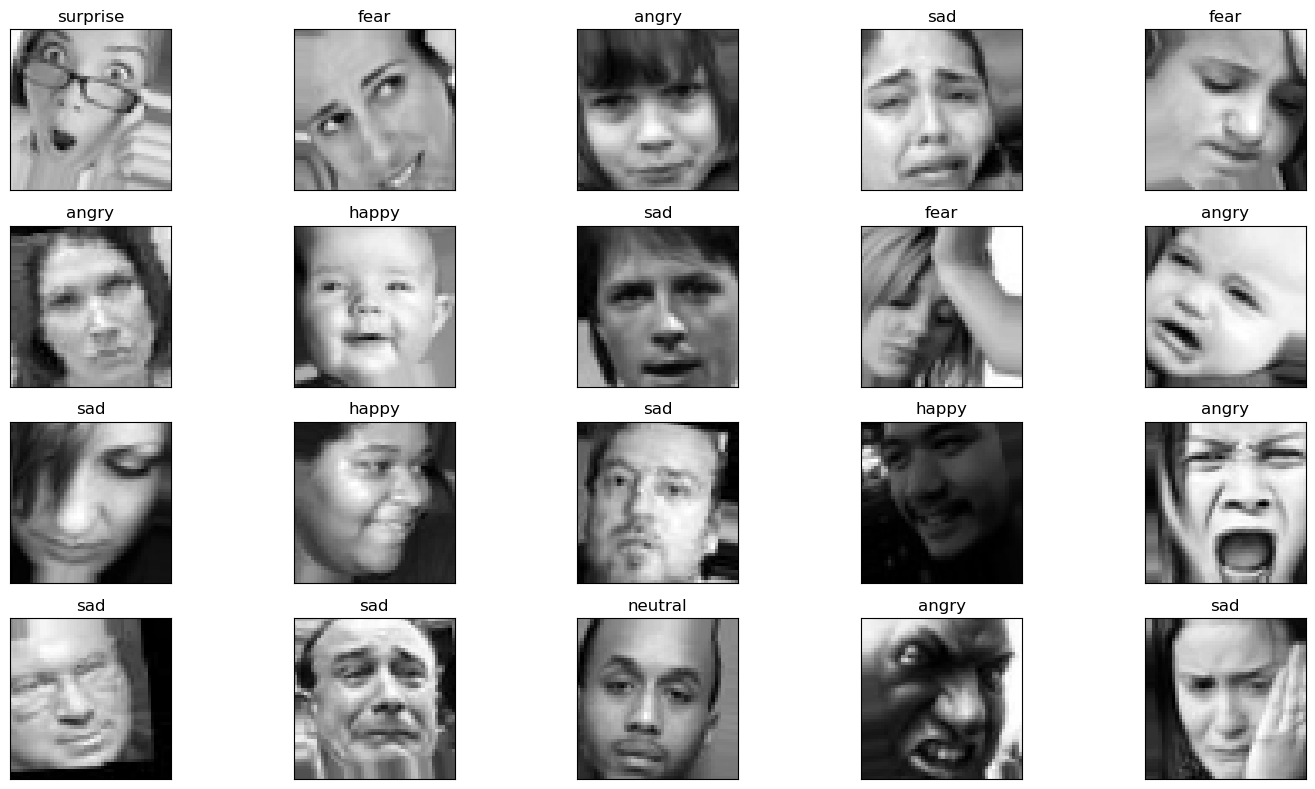

[18:02:07] FINE - Anteprima batch di training (0.5s)


In [11]:
with timed_step("Anteprima batch di training"):
    images, labels = next(train_generator)
    num_images = min(20, len(images))

    log_step(f"Mostro {num_images} immagini augmentate dal primo batch")

    fig = plt.figure(figsize=(15, 8))
    for i in range(num_images):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        class_index = np.argmax(labels[i])
        ax.imshow(images[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
        ax.set_title(emotion_labels[class_index])

    plt.tight_layout()
    plt.show()


## Modello CNN

In [13]:
with timed_step("Costruzione e compilazione modello CNN"):
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

    modelCNN = Sequential([
        Input(shape=input_shape),

        Conv2D(16, (3, 3), padding="same"),
        Activation("relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(32, (3, 3), padding="same"),
        Activation("relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), padding="same"),
        Activation("relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), padding="same"),
        Activation("relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        GlobalAveragePooling2D(),

        Dense(128, activation="relu"),
        Dropout(0.4),

        Dense(train_generator.num_classes, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

    modelCNN.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    modelCNN.summary()


[18:03:29] INIZIO - Costruzione e compilazione modello CNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,527 (451.28 KB)

 Trainable params: 115,047 (449.40 KB)

 Non-trainable params: 480 (1.88 KB)

[18:03:29] FINE - Costruzione e compilazione modello CNN (0.1s)


## Training

In [14]:
import sys
import os
from tensorflow.keras.callbacks import CSVLogger

# Forza il ripristino del modulo originale pulito direttamente dal sistema
datetime_module = sys.modules['datetime']
# Sistema log_step all'origine
log_step.__globals__['datetime'] = datetime_module.datetime 

with timed_step("Training modello"):
    # Usa direttamente la classe estratta dal modulo pulito
    timestamp = datetime_module.datetime.now().strftime("%Y%m%d-%H%M%S")
    model_name = "CNN_v1"
    
    specific_model_dir = project_root / "models" / f"{model_name}_{timestamp}"
    specific_model_dir.mkdir(parents=True, exist_ok=True)

    best_model_path = specific_model_dir / "best_cnn.keras"
    history_csv_path = specific_model_dir / "training_history.csv"
    log_output_path = specific_model_dir / "training_log.txt"

    log_step(f"I risultati del modello verranno salvati in: {specific_model_dir}")
    log_step("Callback attivi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, EpochTimingLogger, CSVLogger")

    callbacks = [
        EpochTimingLogger(),
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        ModelCheckpoint(str(best_model_path), monitor="val_loss", save_best_only=True),
        CSVLogger(str(history_csv_path), separator=",", append=False)
    ]

    history = modelCNN.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    best_val_loss = min(history.history["val_loss"])
    best_epoch = history.history["val_loss"].index(best_val_loss) + 1
    
    summary_message = f"Migliore val_loss: {best_val_loss:.4f} all'epoca {best_epoch}"
    log_step(summary_message)
    
    with open(log_output_path, "w") as f:
        f.write(f"Modello: {model_name}\n")
        f.write(f"Data: {timestamp}\n")
        f.write(f"{summary_message}\n")

[18:03:49] INIZIO - Training modello
[18:03:49] I risultati del modello verranno salvati in: c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\models\CNN_v1_20260627-180349
[18:03:49] Callback attivi: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, EpochTimingLogger, CSVLogger
[18:03:49] Training avviato
[18:03:49] Epoca 1 avviata
Epoch 1/50
1004/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1793 - auc: 0.5613 - loss: 2.0256[18:04:29] Epoca 1 completata in 40.4s - loss=1.9516 | accuracy=0.1888 | auc=0.5759 | val_loss=1.8308 | val_accuracy=0.2656 | val_auc=0.6561 | lr=3.00e-04
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.1888 - auc: 0.5759 - loss: 1.9516 - val_accuracy: 0.2656 - val_auc: 0.6561 - val_loss: 1.8308 - learning_rate: 3.0000e-04
[18:04:29] Epoca 2 avviata
Epoch 2/50
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2322 - auc: 0.6217 - loss: 1.8711[18:05:12] Epoca 2 completata in 42.5s - loss=1.8462 | accuracy=0.2477 | auc=0.6380 | val_l

## Curve di apprendimento

[18:37:13] INIZIO - Creazione curve di apprendimento


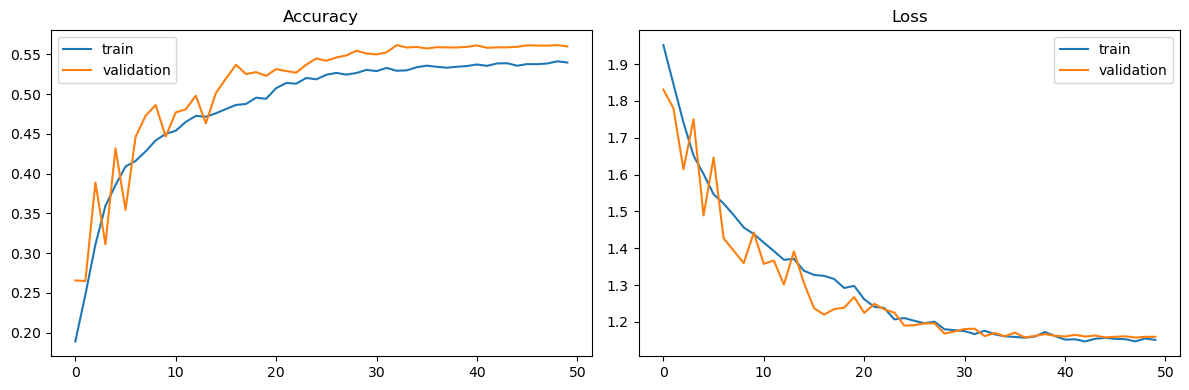

[18:37:13] FINE - Creazione curve di apprendimento (0.3s)


In [15]:
with timed_step("Creazione curve di apprendimento"):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="validation")
    plt.title("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


## Valutazione finale sul test set

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

with timed_step("Valutazione finale sul test set"):
    log_step("Eseguo model.evaluate sul test set")
    test_loss, test_accuracy, test_auc = modelCNN.evaluate(test_generator, verbose=1)
    
    # 1. Definiamo il percorso del file di log dei risultati del test
    # (specific_model_dir è la stessa cartella creata nella cella di training)
    test_results_path = specific_model_dir / "test_results.txt"
    
    log_step(f"Test loss: {test_loss:.4f}")
    log_step(f"Test accuracy: {test_accuracy:.4f}")
    log_step(f"Test AUC: {test_auc:.4f}")

    log_step("Calcolo predizioni sul test set")
    y_true = test_generator.classes
    y_pred_proba = modelCNN.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    target_names = [emotion_labels[i] for i in range(len(emotion_labels))]
    
    # Genereiamo i report in formato stringa per poterli scrivere su file
    class_report = classification_report(y_true, y_pred, target_names=target_names)
    conf_matrix = confusion_matrix(y_true, y_pred)
    
    log_step("Classification report")
    print(class_report)
    
    log_step("Confusion matrix")
    print(conf_matrix)

    # 2. Salviamo tutto nel file test_results.txt all'interno della cartella del modello
    with open(test_results_path, "w") as f:
        f.write("=== VALUTAZIONE FINALE SUL TEST SET ===\n\n")
        f.write(f"Test Loss: {test_loss:.4f}\n")
        f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
        f.write(f"Test AUC: {test_auc:.4f}\n\n")
        f.write("=== CLASSIFICATION REPORT ===\n")
        f.write(class_report)
        f.write("\n=== CONFUSION MATRIX ===\n")
        f.write(np.array2string(conf_matrix)) # Converte la matrice in stringa leggibile
        
    log_step(f"Risultati del test salvati con successo in: {test_results_path}")

[18:37:15] INIZIO - Valutazione finale sul test set
[18:37:15] Eseguo model.evaluate sul test set
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5592 - auc: 0.8854 - loss: 1.1599
[18:37:21] Test loss: 1.1599
[18:37:21] Test accuracy: 0.5592
[18:37:21] Test AUC: 0.8854
[18:37:21] Calcolo predizioni sul test set
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
[18:37:24] Classification report
              precision    recall  f1-score   support

       angry       0.45      0.54      0.49       958
     disgust       0.23      0.68      0.34       111
        fear       0.41      0.21      0.28      1024
       happy       0.84      0.77      0.80      1774
     neutral       0.48      0.66      0.55      1233
         sad       0.48      0.31      0.38      1247
    surprise       0.63      0.78      0.70       831

    accuracy                           0.56      7178
   macro avg       0.50      0.56      0.51      7178
weighted avg       0.57      0.56      0.55      7178

[18:37: